# 鸢尾花分析

## 1.鸢尾花数据集加载

In [ ]:
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 鸢尾花数据集封装在sklearn中，不需要单独下载，从sklear中导入即可

iris_dataset = load_iris()

# 查看鸢尾花数据集的键
print(iris_dataset.keys())

由上结果可知，该数据集的表头有 `['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename']`。  
其中：

- `DESCR` 是数据集的简要说明
- `target_names` 是花的品种
- `feature_names` 是特征说明

数据存储在 `data` 和 `target` 中，也是本次实验主要采用的字段。

## 2.鸢尾花数据集的data和target字段
**查看data字段数据**

每一列对应的是鸢尾花的四个特征：花萼长度、花萼宽度、花瓣长度和花瓣宽度。

In [30]:
# 将数据集转换为 pandas DataFrame
df = pd.DataFrame(iris_dataset['data'], columns=iris_dataset['feature_names'])

# 输出前五行
print(df.head())

# 查看数据量，共有150朵花
print("shape of data: {}".format(iris_dataset['data'].shape))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
shape of data: (150, 4)


In [31]:
print("target:\n{}".format(iris_dataset['target']))

target:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


**查看target字段**

在鸢尾花数据集中，`target` 字段的值为 0、1 或 2，表示数据集中的三个类别：

- `0` 代表 **Setosa**
- `1` 代表 **Versicolor**
- `2` 代表 **Virginica**

这些数字标签对应着鸢尾花的三个不同品种，每个样本的 `target` 值表示该样本所属的类别。
## 3.一元线性回归

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
均方误差 (MSE): 0.045604284097661846
平均绝对误差 (MAE): 0.16818126256563326
决定系数 (R²): 0.9282562958836972


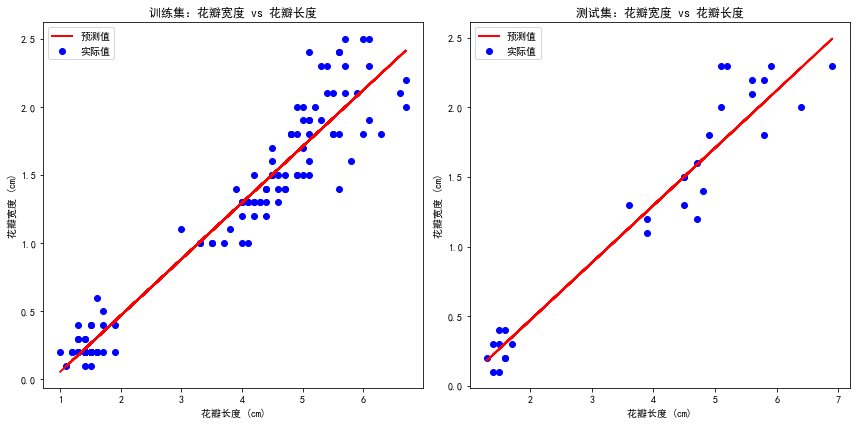

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 设置中文字体为 SimHei（黑体）
rcParams['font.sans-serif'] = ['SimHei']
# 解决负号 '-' 显示问题
rcParams['axes.unicode_minus'] = False

# 加载鸢尾花数据集
iris_dataset = load_iris()

# 转换为DataFrame
df = pd.DataFrame(iris_dataset['data'], columns=iris_dataset['feature_names'])

# 打印数据集的前几行
print(df.head())

# 选择一个特征进行一元回归分析
X = df[['petal length (cm)']]  # 特征：花瓣长度
y = df['petal width (cm)']     # 目标变量：花瓣宽度

# 拆分数据集为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建并训练模型
model = LinearRegression()
model.fit(X_train, y_train)

# 预测
y_pred_train = model.predict(X_train)  # 预测训练集
y_pred_test = model.predict(X_test)    # 预测测试集

# 评估模型
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

# 输出评估结果
print(f"均方误差 (MSE): {mse}")
print(f"平均绝对误差 (MAE): {mae}")
print(f"决定系数 (R²): {r2}")

# 绘制训练集的实际值与预测值的回归图
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # 第一张子图
plt.scatter(X_train, y_train, color='blue', label='实际值')
plt.plot(X_train, y_pred_train, color='red', linewidth=2, label='预测值')
plt.title('训练集：花瓣宽度 vs 花瓣长度')
plt.xlabel('花瓣长度 (cm)')
plt.ylabel('花瓣宽度 (cm)')
plt.legend()

# 绘制测试集的实际值与预测值的回归图
plt.subplot(1, 2, 2)  # 第二张子图
plt.scatter(X_test, y_test, color='blue', label='实际值')
plt.plot(X_test, y_pred_test, color='red', linewidth=2, label='预测值')
plt.title('测试集：花瓣宽度 vs 花瓣长度')
plt.xlabel('花瓣长度 (cm)')
plt.ylabel('花瓣宽度 (cm)')
plt.legend()

# 显示图像
plt.tight_layout()
plt.show()


## 4.随机森林分类（鸢尾花数据集应该是个分类问题，因此应该采用分类而不是回归）
### 1. 准备数据
首先，选择多个特征来训练模型。使用鸢尾花数据集中的四个特征：
- **花萼长度（sepal length）**
- **花瓣长度（petal length）**
- **花萼宽度（sepal width）**
- **花瓣宽度（petal width）**

### 2. 拆分数据集
将数据集按8:1为训练集和测试集

### 3. 训练模型
使用随机森林模型来进行训练。该模型会基于输入的四个特征来预测花的所属类别。通过最小化误差，模型会学习如何从特征中提取有用的信息，从而进行预测。

### 4. 预测与评估
模型完成训练，使用测试集进行预测。通过以下几个评估指标来评估模型的性能：
- **总体精度 (OA):**：正确预测的样本数占总样本数的比例。
- **平均精度 (AA)**：对每个类别的召回率取平均值。
- **Kappa 系数:**：衡量分类模型与随机分类相比的改进程度，取值范围 [-1, 1]，越接近 1 模型性能越好。

### 5. 可视化
最后，绘制混淆矩阵来展示模型的表现。表现好的模型数值应集中在主对角线上。


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
总体精度 (OA): 1.00
平均精度 (AA): 1.00
Kappa 系数: 1.00


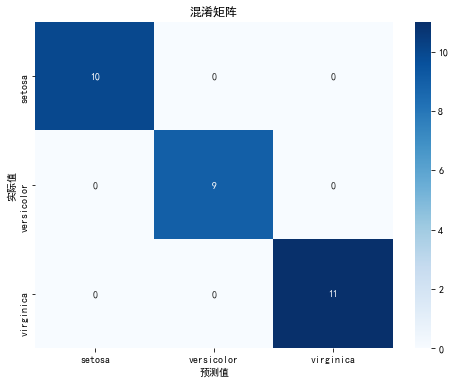

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, cohen_kappa_score, accuracy_score
import seaborn as sns

# 设置中文字体为 SimHei（黑体）
rcParams['font.sans-serif'] = ['SimHei']
# 解决负号 '-' 显示问题
rcParams['axes.unicode_minus'] = False

# 加载鸢尾花数据集
iris_dataset = load_iris()

# 转换为 DataFrame
df = pd.DataFrame(iris_dataset['data'], columns=iris_dataset['feature_names'])
df['target'] = iris_dataset['target']  # 添加目标变量到 DataFrame 中


# 选择特征和目标变量
X = df[['sepal length (cm)', 'petal length (cm)', 'sepal width (cm)', 'petal width (cm)']]  # 特征
y = df['target']  # 目标变量

# 拆分数据集为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建随机森林分类模型
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 预测
y_pred_test = rf_model.predict(X_test)  # 测试集预测

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred_test)

# 计算 OA、AA 和 Kappa 系数
oa = accuracy_score(y_test, y_pred_test)
aa = np.mean(np.diag(cm) / np.sum(cm, axis=1))  # 每类的召回率平均值
kappa = cohen_kappa_score(y_test, y_pred_test)

# 打印评价指标
print(f"总体精度 (OA): {oa:.2f}")
print(f"平均精度 (AA): {aa:.2f}")
print(f"Kappa 系数: {kappa:.2f}")

# 绘制混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=iris_dataset['target_names'], yticklabels=iris_dataset['target_names'])
plt.title("混淆矩阵")
plt.xlabel("预测值")
plt.ylabel("实际值")
plt.show()
